In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Feature<br>
- Q (discharge rate in m3 / s)
- H (water level in cm) **target feature**
- P (precipitation in mm) , water vapor that has condensed from clouds to fall as liquid (rain) or solids (snow, hail).
- T (temperature in Celecius)

Data is recorded on multiple guaged stations. our main focus is Bardejov (_bar).

In [2]:
# Load dataset without interpolation
no_inter_ds = pd.read_csv('data_diff_locations_no_inter.csv',parse_dates=[0], index_col=0, dayfirst=True)
display(no_inter_ds.head(5))
display(no_inter_ds.info())

,Q_bar_Orig,H_bar_Orig,P_ger_Orig,P_Cigelka,P_Regetovka,P_bar,day_of_year,hour_of_day
2005-07-07 08:00:00,3.048,154.0,0.0,0.0,0.0,NaN,188,8
2005-07-07 09:00:00,2.811,153.0,0.0,0.0,0.0,NaN,188,9
2005-07-07 10:00:00,3.048,154.0,0.0,0.0,0.0,NaN,188,10
2005-07-07 11:00:00,3.048,154.0,0.0,0.0,0.0,NaN,188,11
2005-07-07 12:00:00,2.811,153.0,0.0,0.0,0.0,NaN,188,12


<class 'pandas.core.frame.DataFrame'>
Index: 87780 entries, 2005-07-07 08:00:00 to 2019-12-13 20:00:00
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Q_bar_Orig   87780 non-null  float64
 1   H_bar_Orig   87780 non-null  float64
 2   P_ger_Orig   87780 non-null  float64
 3   P_Cigelka    87780 non-null  float64
 4   P_Regetovka  87780 non-null  float64
 5   P_bar        76647 non-null  float64
 6   day_of_year  87780 non-null  int64  
 7   hour_of_day  87780 non-null  int64  
dtypes: float64(6), int64(2)
memory usage: 6.0+ MB


None

In [3]:
# load dataset with interpolation
inter_ds = pd.read_csv('data_diff_locations_inter.csv',parse_dates=[0], index_col=0, dayfirst=True)
display(inter_ds.head(5))
display(inter_ds.info())

,H_bar,Q_bar,T_bar,P_bar,H_kam,Q_kam,T_kam,Q_bar_Orig,H_bar_Orig,P_ger_Orig,P_Cigelka,P_Regetovka,day_of_year,hour_of_day
2008-01-01 00:00:00,153.0,2.216000,0.066667,0.3000,97.000000,0.630917,0.0,2.216,153.0,0.0,0.932,0.0,1,0
2008-01-01 01:00:00,153.0,2.216385,0.068750,0.2875,96.916667,0.625252,0.0,2.216,153.0,0.0,0.492,0.0,1,1
2008-01-01 02:00:00,153.0,2.216771,0.070833,0.2750,96.833333,0.619587,0.0,2.216,153.0,0.0,0.429,0.0,1,2
2008-01-01 03:00:00,153.0,2.217156,0.072917,0.2625,96.750000,0.613922,0.0,2.216,153.0,0.0,1.594,0.0,1,3
2008-01-01 04:00:00,153.0,2.217542,0.075000,0.2500,96.666667,0.608257,0.0,2.216,153.0,0.0,0.071,0.0,1,4


<class 'pandas.core.frame.DataFrame'>
Index: 76647 entries, 2008-01-01 00:00:00 to 2019-12-13 20:00:00
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   H_bar        76647 non-null  float64
 1   Q_bar        76647 non-null  float64
 2   T_bar        76647 non-null  float64
 3   P_bar        76647 non-null  float64
 4   H_kam        76647 non-null  float64
 5   Q_kam        76647 non-null  float64
 6   T_kam        76647 non-null  float64
 7   Q_bar_Orig   76647 non-null  float64
 8   H_bar_Orig   76647 non-null  float64
 9   P_ger_Orig   76647 non-null  float64
 10  P_Cigelka    76647 non-null  float64
 11  P_Regetovka  76647 non-null  float64
 12  day_of_year  76647 non-null  int64  
 13  hour_of_day  76647 non-null  int64  
dtypes: float64(12), int64(2)
memory usage: 8.8+ MB


None

In [4]:
# creating a simplified dataset from the interpolated one
simple_ds = inter_ds[['Q_bar',  'P_bar', 'T_bar', 'H_bar']]
display(simple_ds.head(5))
display(simple_ds.info())

,Q_bar,P_bar,T_bar,H_bar
2008-01-01 00:00:00,2.216000,0.3000,0.066667,153.0
2008-01-01 01:00:00,2.216385,0.2875,0.068750,153.0
2008-01-01 02:00:00,2.216771,0.2750,0.070833,153.0
2008-01-01 03:00:00,2.217156,0.2625,0.072917,153.0
2008-01-01 04:00:00,2.217542,0.2500,0.075000,153.0


<class 'pandas.core.frame.DataFrame'>
Index: 76647 entries, 2008-01-01 00:00:00 to 2019-12-13 20:00:00
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Q_bar   76647 non-null  float64
 1   P_bar   76647 non-null  float64
 2   T_bar   76647 non-null  float64
 3   H_bar   76647 non-null  float64
dtypes: float64(4)
memory usage: 2.9+ MB


None

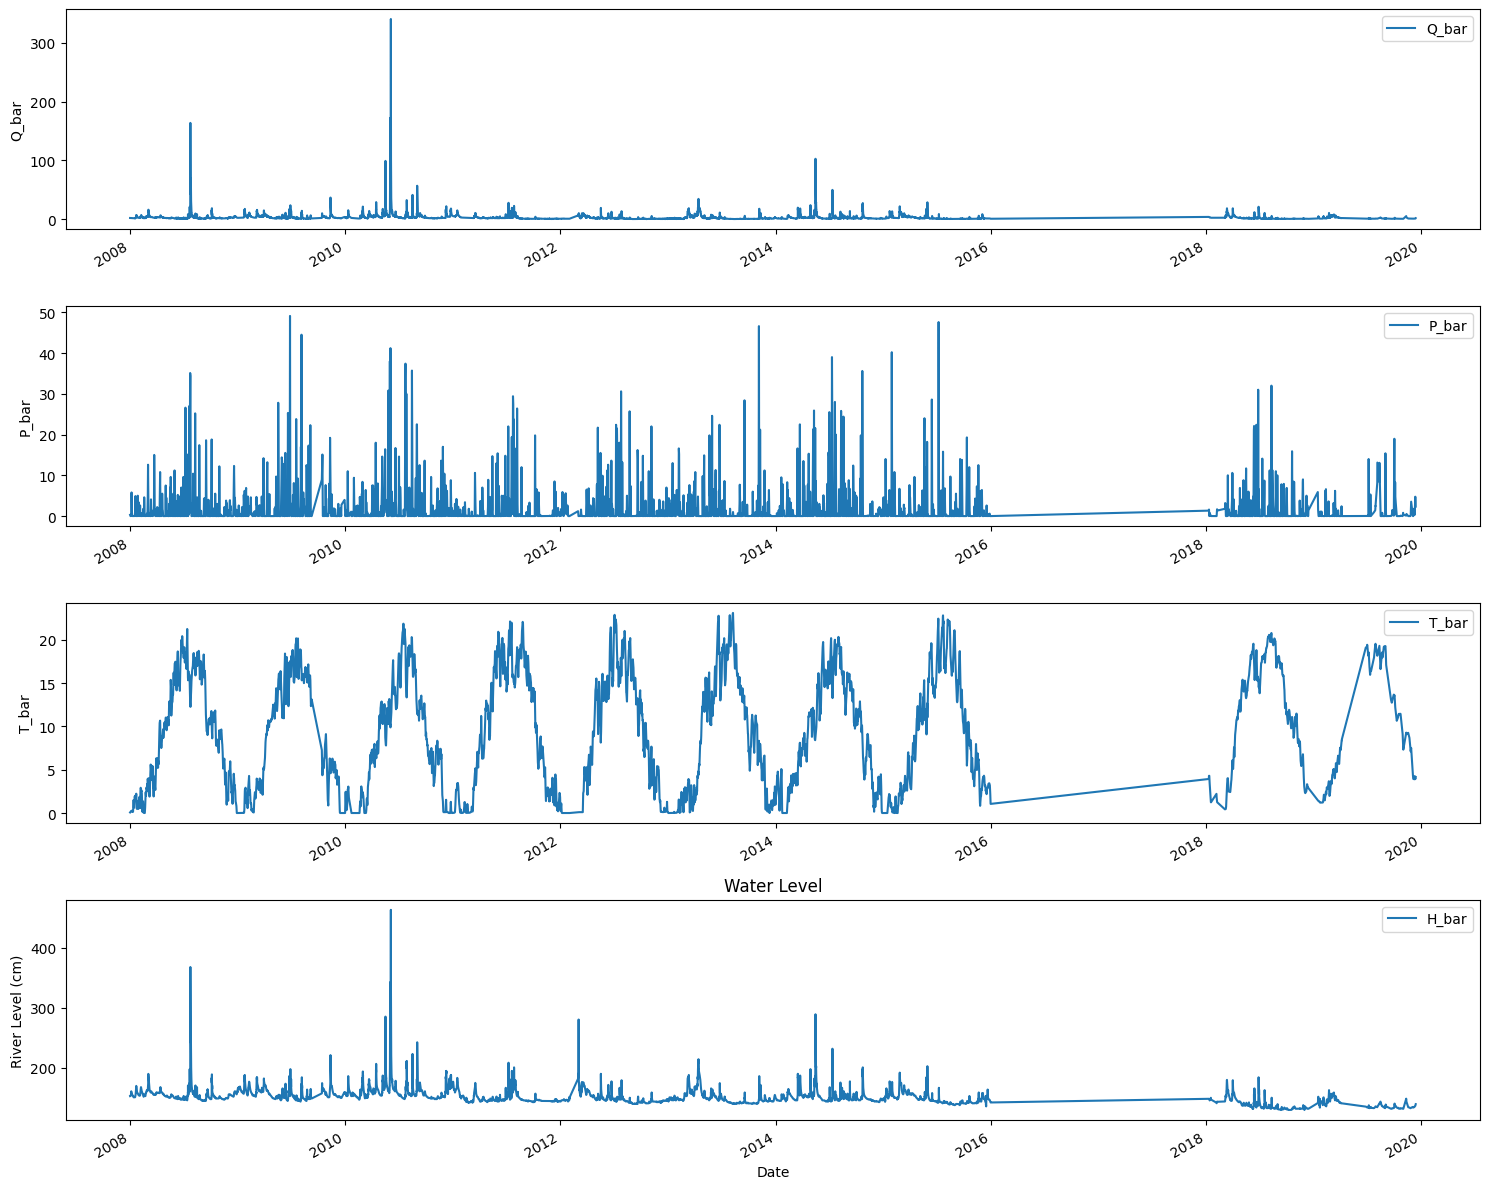

In [5]:
import matplotlib.dates as mdates

fig, axes = plt.subplots(len(simple_ds.columns), 1, figsize=(15, 12))
simple_ds.index = pd.to_datetime(simple_ds.index)

for i, column in enumerate(simple_ds.columns, 1):
    ax = axes[i-1]
    simple_ds.plot(y=column, ax=ax)
    ax.set_ylabel(column)
    if column == 'H_bar':
        ax.set_title('Water Level')
        ax.set_ylabel('River Level (cm)')
    # Fix the crowded date formatting without making figure bigger
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax.xaxis.set_major_formatter(mdates.AutoDateFormatter(mdates.AutoDateLocator()))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

plt.xlabel('Date')
plt.tight_layout()



### Note :  
we can splot that data from 2016 to 2018 is missing in the dataset

In [6]:
simple_ds[(simple_ds.index >= "2016") & (simple_ds.index < "2018")].info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 0 entries
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Q_bar   0 non-null      float64
 1   P_bar   0 non-null      float64
 2   T_bar   0 non-null      float64
 3   H_bar   0 non-null      float64
dtypes: float64(4)
memory usage: 0.0 bytes


## Training and testing data
Trainging dataset : same interpolated data but without years (2008 and 2014).<br>
testing dataset: values of bar station in years (2008 and 2014).

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 59121 entries, 2009-01-01 01:00:00 to 2019-12-13 20:00:00
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Q_bar   59121 non-null  float64
 1   P_bar   59121 non-null  float64
 2   T_bar   59121 non-null  float64
 3   H_bar   59121 non-null  float64
dtypes: float64(4)
memory usage: 2.3 MB


None

Text(0.5, 0, 'Date')

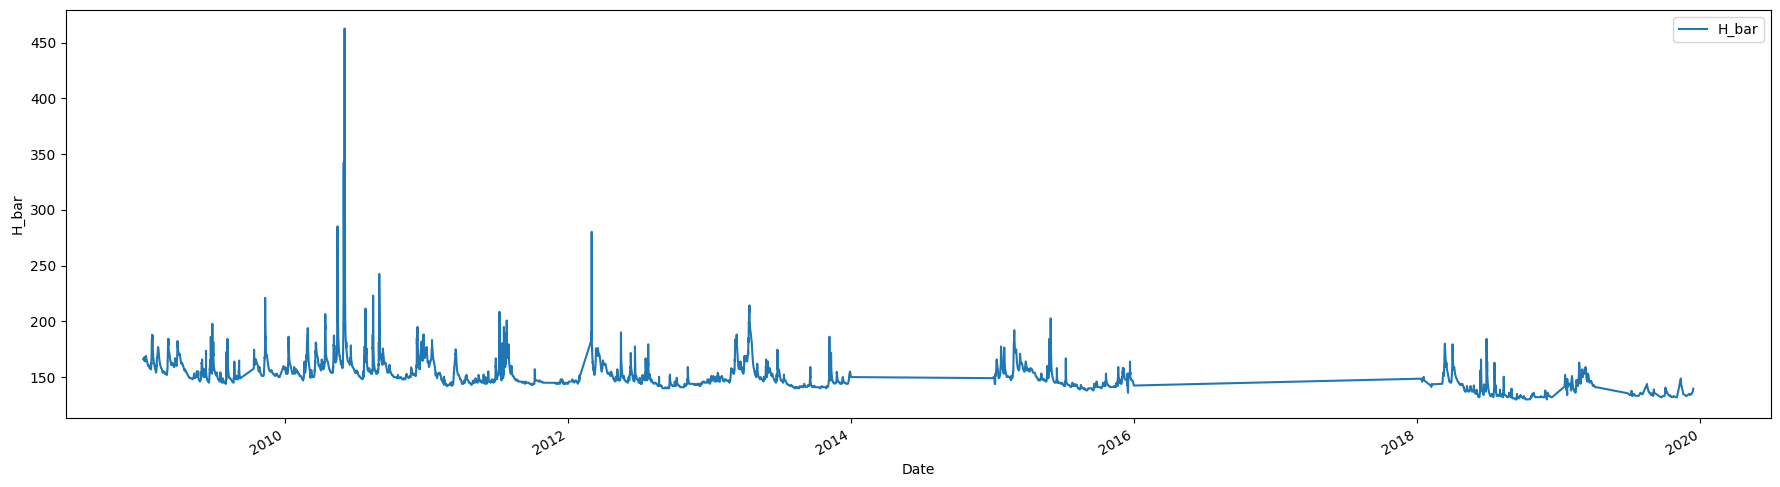

In [7]:
train_data = simple_ds[(simple_ds.index > "2009") & (simple_ds.index < "2014")]
train_data = pd.concat([train_data, simple_ds[simple_ds.index > "2015"]],ignore_index=False)
display(train_data.info())
train_data.plot(y='H_bar', figsize=(22,6))
train_data.to_csv('one_station_train_data.csv')
# simple plot to verfiy the effect of filtering
plt.ylabel(column)
plt.xlabel('Date')

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 33769 entries, 2008-01-01 00:00:00 to 2015-12-31 13:00:00
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Q_bar   33769 non-null  float64
 1   P_bar   33769 non-null  float64
 2   T_bar   33769 non-null  float64
 3   H_bar   33769 non-null  float64
dtypes: float64(4)
memory usage: 1.3 MB


<Axes: >

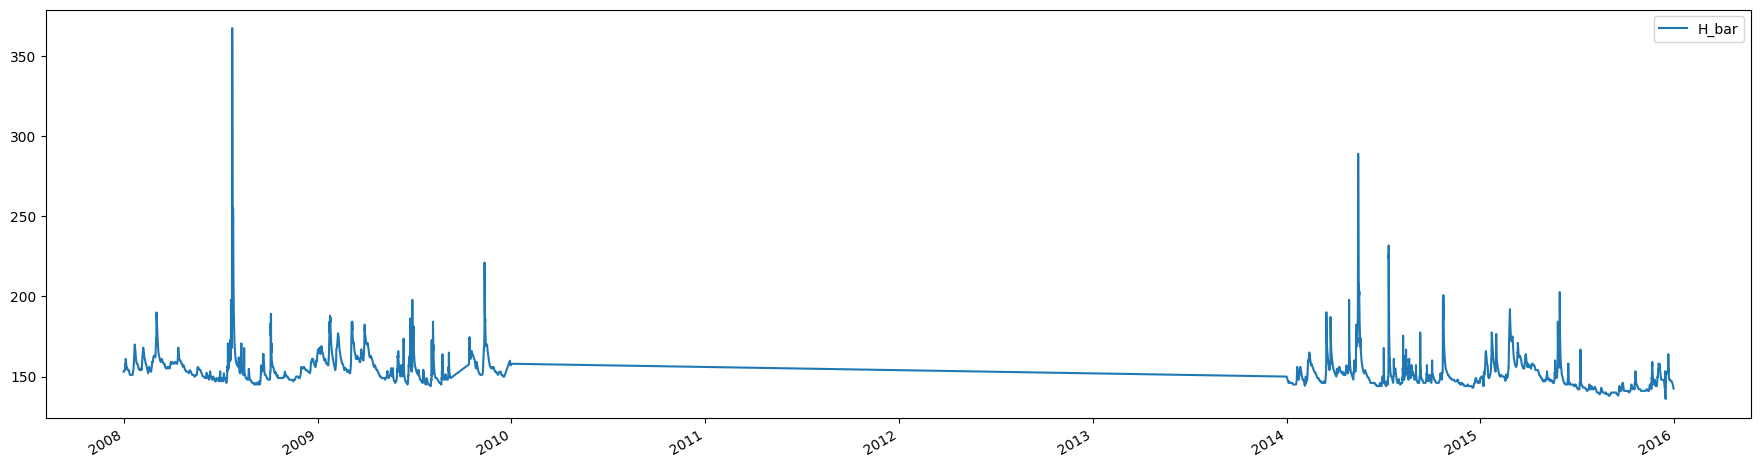

In [8]:
data_2008 = simple_ds["2008" : '2009']
data_2014 = simple_ds["2014" : '2015']
test_data = pd.concat([data_2008, data_2014],ignore_index=False)
test_data.info()
test_data.to_csv('one_station_test_data.csv')
test_data.plot(y='H_bar', figsize=(22,6))